In [1]:
import numpy as np
import pandas as pd
import seaborn as sc
import matplotlib.pylab as plt

df  = pd.read_csv('ma_lga_12345.csv')

In [2]:
df.head()

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   saledate  347 non-null    str  
 1   MA        347 non-null    int64
 2   type      347 non-null    str  
 3   bedrooms  347 non-null    int64
dtypes: int64(2), str(2)
memory usage: 15.9 KB


In [4]:
df.describe()

,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


In [5]:
np.mean(df['MA'])

np.float64(548131.9798270894)

<Axes: xlabel='MA', ylabel='Count'>

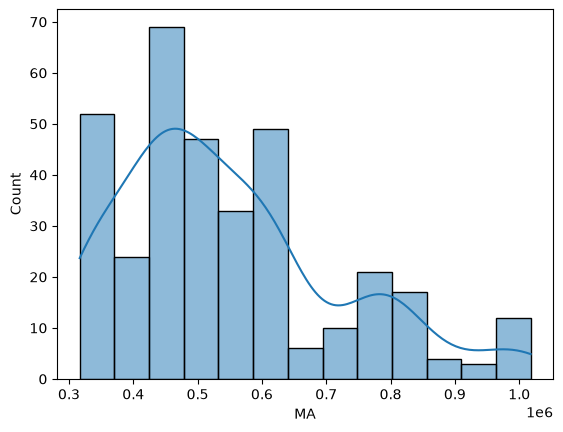

In [6]:
sc.histplot(df['MA'], kde=True)

<Axes: xlabel='bedrooms', ylabel='count'>

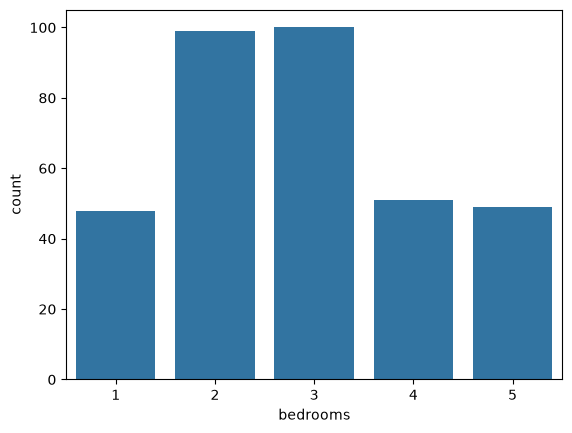

In [9]:
sc.countplot(x= df['bedrooms'])

<Axes: >

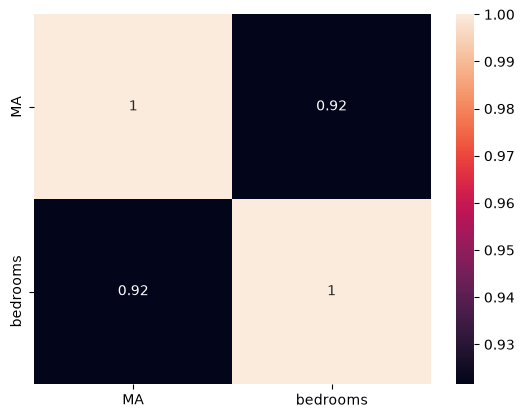

In [12]:
sc.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='bedrooms', ylabel='MA'>

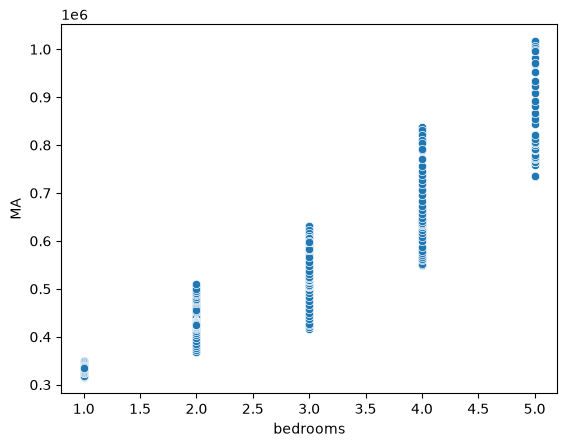

In [13]:
sc.scatterplot(data=df, x= 'bedrooms', y='MA')

<Axes: xlabel='bedrooms', ylabel='MA'>

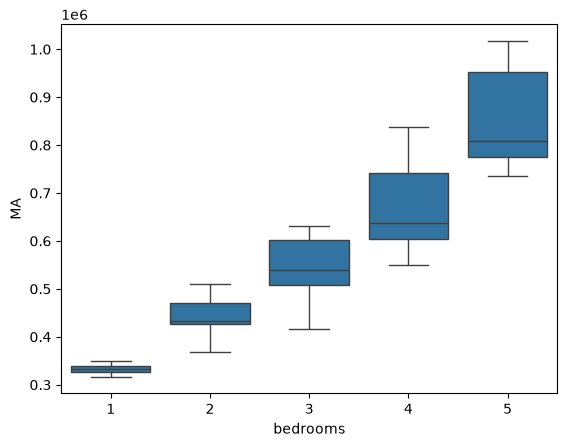

In [14]:
sc.boxplot(data=df, x= 'bedrooms', y='MA')

In [15]:
df.head()

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


<Axes: xlabel='saledate', ylabel='MA'>

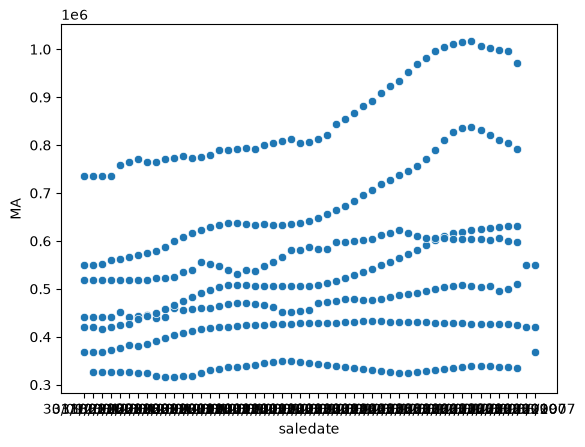

In [18]:
sc.scatterplot(data = df, x= 'saledate', y='MA')

<Axes: xlabel='MA'>

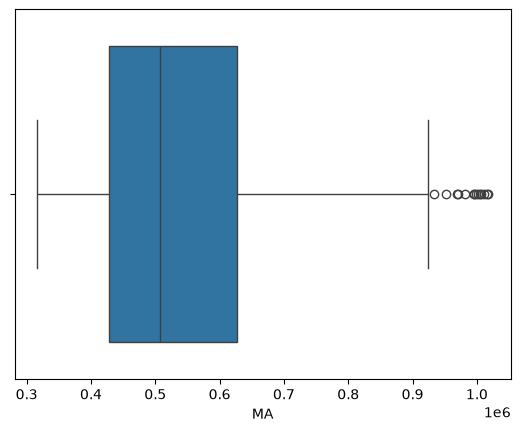

In [21]:
sc.boxplot(x= df['MA'])

In [22]:
df.isnull().sum()

saledate    0
MA          0
type        0
bedrooms    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [27]:
X = df.drop(columns=['MA'])
Y = df['MA']

In [29]:
Y

0      441854
1      441854
2      441854
3      441854
4      451583
        ...  
342    603281
343    601167
344    605637
345    599339
346    597884
Name: MA, Length: 347, dtype: int64

In [30]:
X.head()

,saledate,type,bedrooms
0,30/09/2007,house,2
1,31/12/2007,house,2
2,31/03/2008,house,2
3,30/06/2008,house,2
4,30/09/2008,house,2


In [ ]:
X['saledate'].value_counts()

np.int64(347)

In [39]:
X['year'] = pd.to_datetime(X['saledate']).dt.year.astype(int)

C:\Users\Anuj\AppData\Local\Temp\ipykernel_14200\3338634106.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X['year'] = pd.to_datetime(X['saledate']).dt.year.astype(int)


In [40]:
X.head()

,saledate,type,bedrooms,year
0,30/09/2007,house,2,2007
1,31/12/2007,house,2,2007
2,31/03/2008,house,2,2008
3,30/06/2008,house,2,2008
4,30/09/2008,house,2,2008


In [42]:
X = X.drop(columns=['saledate'])

In [46]:
X.head()

,type,bedrooms,year
0,house,2,2007
1,house,2,2007
2,house,2,2008
3,house,2,2008
4,house,2,2008


In [43]:
X_Encode = pd.get_dummies(X, columns=['type'], drop_first=True)

In [44]:
X_Encode = X_Encode.astype(int)

In [45]:
X_Encode.head()

,bedrooms,year,type_unit
0,2,2007,0
1,2,2007,0
2,2,2008,0
3,2,2008,0
4,2,2008,0


In [47]:
X['bedrooms'].value_counts()

bedrooms
3    100
2     99
4     51
5     49
1     48
Name: count, dtype: int64

In [50]:
col = ['bedrooms','year']

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_Encode[col] = scaler.fit_transform(X_Encode[col])

In [53]:
X_Encode.head()

,bedrooms,year,type_unit
0,-0.700625,-1.683709,0
1,-0.700625,-1.683709,0
2,-0.700625,-1.405496,0
3,-0.700625,-1.405496,0
4,-0.700625,-1.405496,0


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, Y_train, Y_tesr = train_test_split(X_Encode,Y,test_size=0.35, random_state=45 )

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
model = LinearRegression()

In [58]:
model.fit(X_train, Y_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[160181.85, 50155.27, 6675.79]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['bedrooms','year','type_unit']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.454e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [59]:
pr = model.predict(X_test)

In [60]:
pr

array([638297.69046918, 362704.96840418, 610390.01112274, 488289.52546317,
       607508.19878547, 390612.64775063, 663323.55747835, 610390.01112274,
       890378.97021814, 547898.86212432, 719138.91617123, 502243.36513639,
       806655.93217882, 645575.73983686, 323725.2617218 , 383334.59838294,
       806655.93217882, 568528.49210308, 568528.49210308, 418520.32709707,
       460381.84611673, 439149.95707583, 733092.75584445, 596436.17144952,
       582482.3317763 , 750840.57348594, 554574.65242986, 806655.93217882,
       240002.22368247, 617668.06049042, 240002.22368247, 733092.75584445,
       519991.18277788, 561852.70179754, 547898.86212432, 425196.11740261,
       512713.1334102 , 519991.18277788, 834563.61152526, 635415.87813191,
       677277.39715157, 834563.61152526, 624343.85079596, 355426.9190365 ,
       607508.19878547, 379540.62041468, 649369.71780513, 561852.70179754,
       397288.43805616, 691231.23682479, 631621.90016364, 362704.96840418,
       876425.13054492, 6

In [61]:
from sklearn.metrics import r2_score

In [64]:
r = r2_score(Y_tesr,pr)
r

0.9145987273251591

In [65]:
n = X_test.shape[0]
p = X_test.shape[1]
adjust_r2 = (1 -(1-r) * (n-1) / (n - p -1))
adjust_r2

0.9124275085283411